In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
#pd.set_option('display.max_columns', 1500)

In [2]:
df = pd.read_csv('../data/raw/Metal Deposition.csv')

In [3]:
epi_tool = df[df["Tool ID"] == 0].copy()

## Tool Parameters
Input 1 range: 1000-1400, aggression: 8
Input 2 range: 50-80, aggression: 3
Output range: 0.5-2

In [4]:
epi_tool.head(10)

,Tool Group,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output,Failed
0,Metal Deposition,0,3,601,716,1358.505420,1.801709,4.889790,False
1,Metal Deposition,0,2,811,892,1327.781592,2.220154,4.790299,False
4,Metal Deposition,0,5,1056,1157,1283.375507,2.447867,4.665897,False
6,Metal Deposition,0,9,1668,1772,1261.897241,4.092477,4.332349,False
7,Metal Deposition,0,1,1797,1885,1234.767206,4.633690,4.126935,False
8,Metal Deposition,0,14,1922,2006,1184.542864,4.932950,3.904630,False
10,Metal Deposition,0,12,2094,2198,1174.056980,6.297045,3.410870,False
12,Metal Deposition,0,10,2446,2552,1152.978251,7.608510,2.781951,True
14,Metal Deposition,0,19,2662,2773,1353.477840,1.169009,4.904469,False
15,Metal Deposition,0,21,2773,2873,1327.210346,1.829449,4.820330,False


## Holistic View of Data

In [5]:
epi_tool.describe()

,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output
count,6379.0,6379.000000,6.379000e+03,6.379000e+03,6379.000000,6379.000000,6379.000000
mean,0.0,7798.182160,7.857263e+05,7.858259e+05,1191.550201,4.100303,4.024061
std,0.0,4499.651407,4.555981e+05,4.555981e+05,117.313496,1.671850,0.691461
min,0.0,1.000000,6.010000e+02,7.160000e+02,840.378305,1.067512,2.095783
25%,0.0,3893.000000,3.903625e+05,3.904810e+05,1102.087475,2.681349,3.475221
50%,0.0,7813.000000,7.835730e+05,7.836760e+05,1196.790134,4.089250,4.148300
75%,0.0,11689.500000,1.182190e+06,1.182285e+06,1290.087104,5.468824,4.634381
max,0.0,15597.000000,1.576397e+06,1.576509e+06,1396.637530,8.466671,4.990183


The average of the inputs seem to be within the ranges of the tool.

## Univariate Distributions

Looking at Inputs first, ensuring monotonic drift:

Text(0, 0.5, 'Runs')

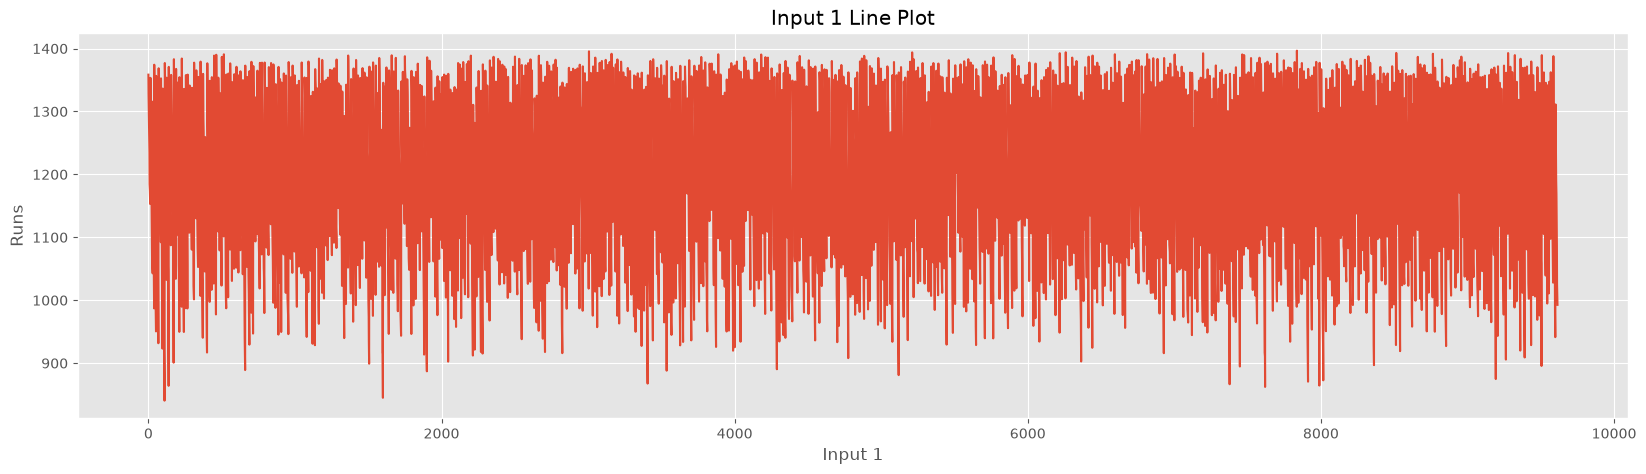

In [6]:
plt.figure(figsize=(20, 5))
line = epi_tool['Input 1'].plot(kind='line', title="Input 1 Line Plot")
line.set_xlabel('Input 1')
line.set_ylabel('Runs')

Text(0, 0.5, 'Runs')

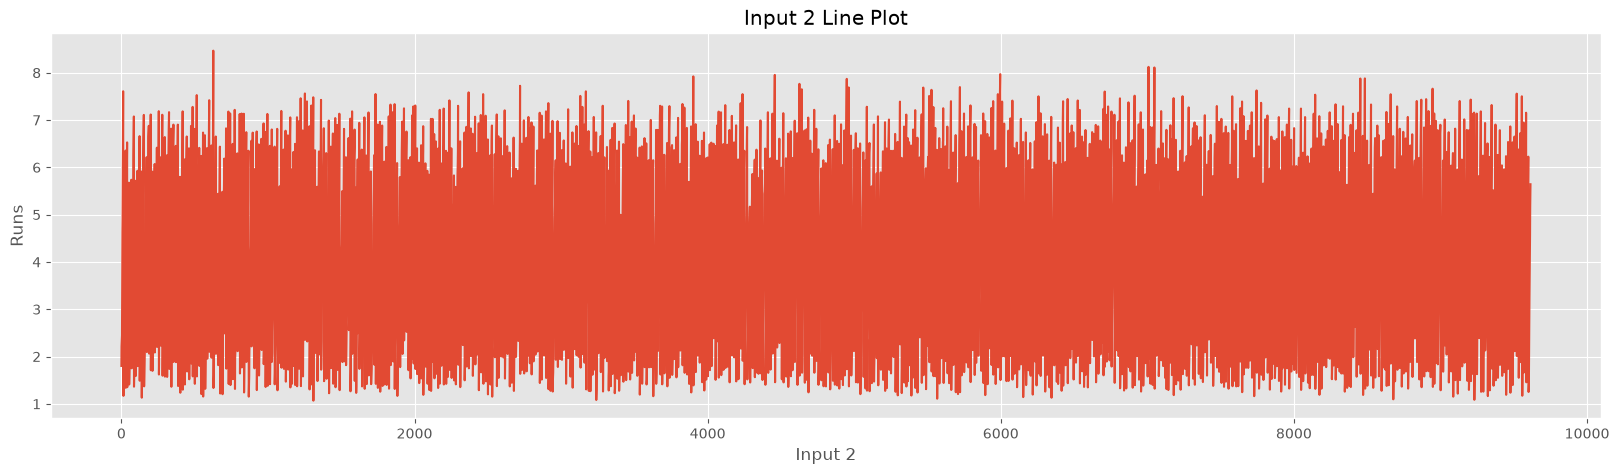

In [7]:
plt.figure(figsize=(20, 5))
line = epi_tool['Input 2'].plot(kind='line', title="Input 2 Line Plot")
line.set_xlabel('Input 2')
line.set_ylabel('Runs')

Both are showing what would be expected from degradation-driven inputs. Both show monotonic drift, although the noise in Input 2 seems to have a greater relative effect since Input 2 is much smaller in terms of magnitude.

Now an analysis of output

Text(0, 0.5, 'Runs')

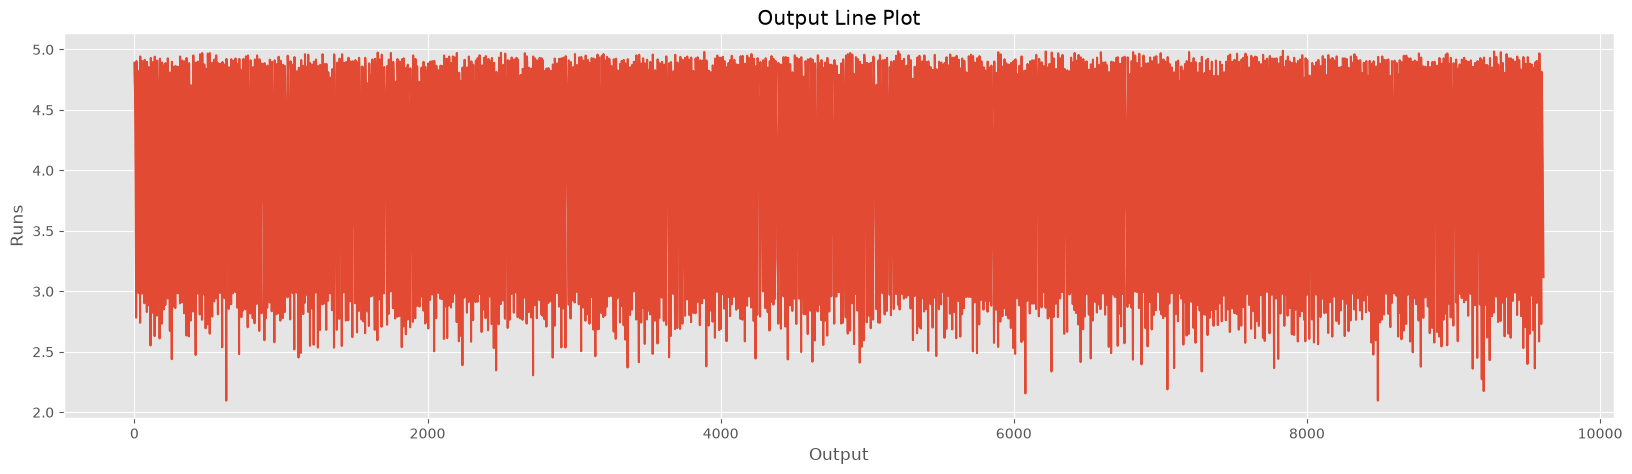

In [8]:
plt.figure(figsize=(20, 5))
line = epi_tool['Output'].plot(kind='line', title="Output Line Plot")
line.set_xlabel('Output')
line.set_ylabel('Runs')

<Axes: >

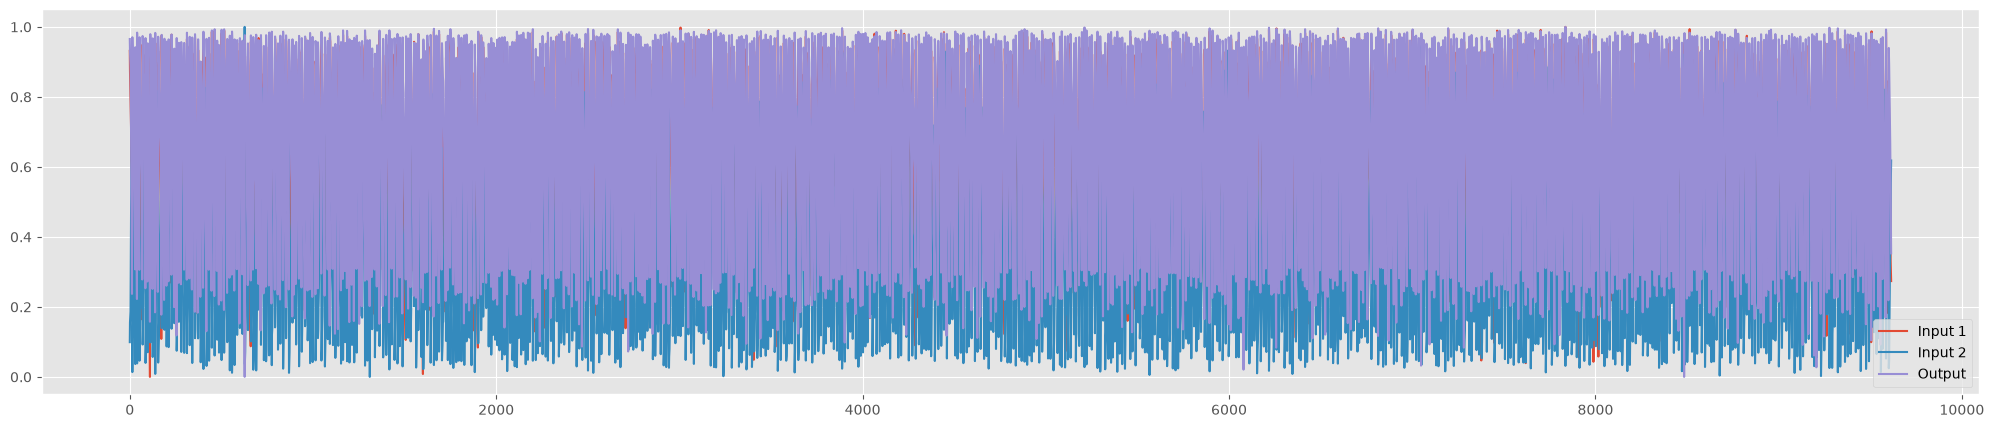

In [9]:
df_norm = (epi_tool[['Input 1', 'Input 2', 'Output']] - epi_tool[['Input 1', 'Input 2', 'Output']].min()) / \
          (epi_tool[['Input 1', 'Input 2', 'Output']].max() - epi_tool[['Input 1', 'Input 2', 'Output']].min())
df_norm.plot(kind='line',figsize=(25, 5))


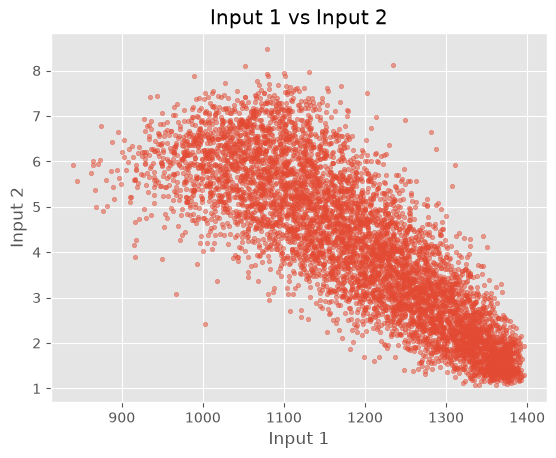

In [10]:
plt.scatter(epi_tool['Input 1'], epi_tool['Input 2'], alpha=0.5, s=10)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Input 1 vs Input 2')
plt.show()

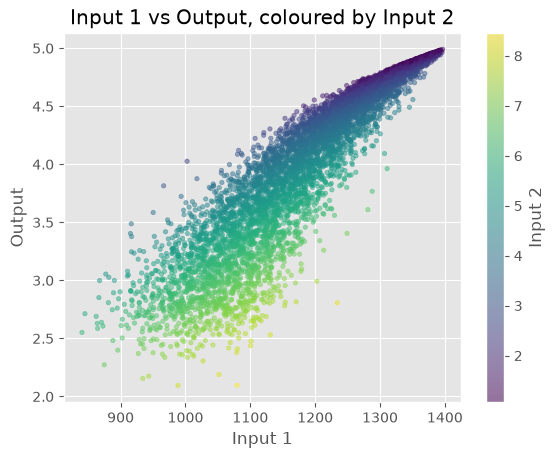

In [11]:
scatter = plt.scatter(epi_tool['Input 1'], epi_tool['Output'], c=epi_tool['Input 2'], alpha=0.5, s=10, cmap='viridis')
plt.xlabel('Input 1')
plt.ylabel('Output')
plt.colorbar(scatter, label='Input 2')
plt.title('Input 1 vs Output, coloured by Input 2')
plt.show()

In [12]:
epi_tool[['Input 1', 'Input 2', 'Output']].corr()

,Input 1,Input 2,Output
Input 1,1.000000,-0.835766,0.925888
Input 2,-0.835766,1.000000,-0.960402
Output,0.925888,-0.960402,1.000000


In [13]:
epi_tool['Input 2'].pow(2).corr(epi_tool['Output'])

np.float64(-0.9650990568293409)

As expected, Input 1 has a strong linear relationship with Output. Within the formula, Input 1 has a direct linear term in the formula used. Surprisingly, Input 2 also has a strong pairwise correlation (as input 2 is a non linear term in the equation),  potentially explained by Input 2 having a much narrower range, so its quadratic contribution does not have enough room to show its non-linearity. A look into the pearson correlation between Input 2 squared and output shows near enough the same value, confirming that the range is too narrow to see meaningful non-linear trends.

## Calculating RUL and observing individual variable effects on RUL

In [14]:
epi_tool["Shifted"] = epi_tool["Failed"].shift(periods=1, fill_value= False)
epi_tool["Cycle Group"] = epi_tool["Shifted"].cumsum()
epi_tool["Forward"] = epi_tool.groupby(["Cycle Group"]).cumcount()
epi_tool["Cycle Size"] = epi_tool.groupby("Cycle Group")["Failed"].transform("size")
epi_tool["RUL"] = epi_tool["Cycle Size"] - epi_tool["Forward"] - 1
epi_tool = epi_tool.drop(columns=['Shifted','Cycle Size','Forward'])
last_cycle = epi_tool["Cycle Group"].max()
last_cycle_rows = epi_tool["Cycle Group"] == last_cycle #cycle group as a series of boolean values
last_cycle_has_breach = epi_tool.loc[last_cycle_rows, 'Failed'].any()
if last_cycle_has_breach == False:
    epi_tool = epi_tool[~last_cycle_rows]



<Axes: xlabel='RUL', ylabel='Input 1'>

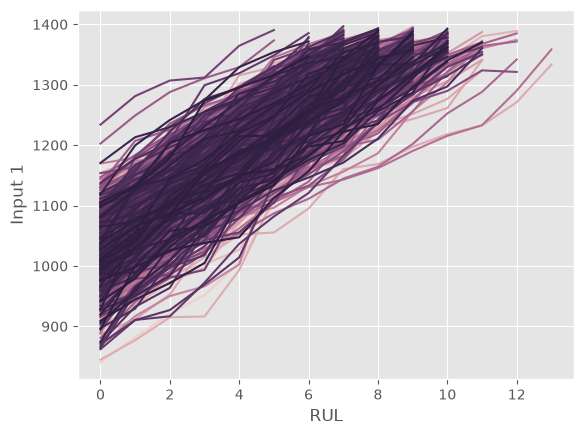

In [15]:
sns.lineplot(data=epi_tool, x="RUL", y="Input 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Input 2'>

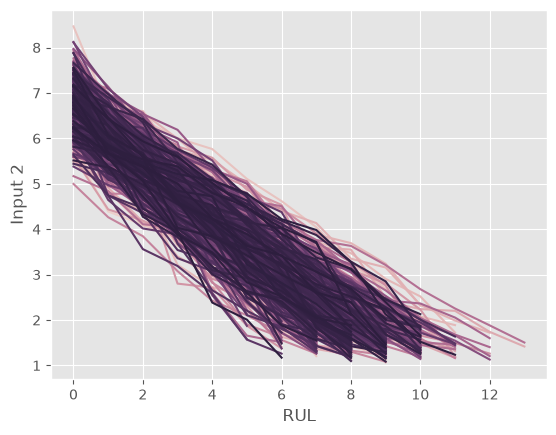

In [16]:
sns.lineplot(data=epi_tool, x="RUL", y="Input 2", hue="Cycle Group", legend = False)

In [17]:
epi_tool["Rolling Mean 1"] = epi_tool.groupby("Cycle Group")["Input 1"].rolling(5).mean().reset_index(level=0,drop=True)
epi_tool["Rolling Mean 2"] = epi_tool.groupby("Cycle Group")["Input 2"].rolling(5).mean().reset_index(level=0,drop=True)


<Axes: xlabel='RUL', ylabel='Rolling Mean 1'>

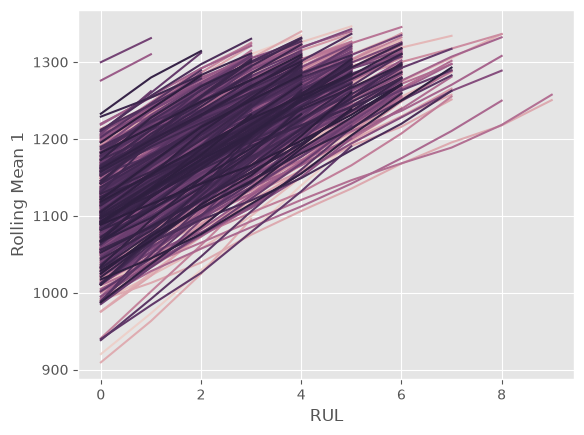

In [18]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Mean 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Mean 2'>

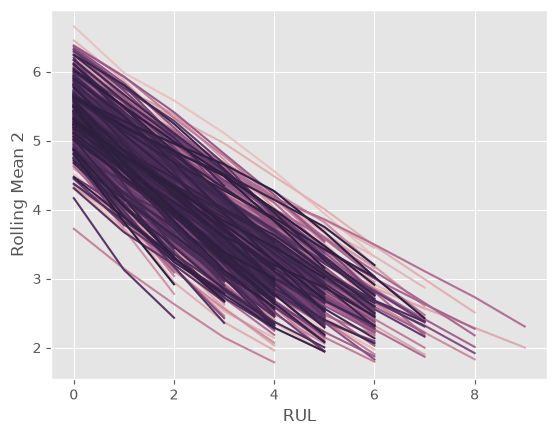

In [19]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Mean 2", hue="Cycle Group", legend = False)

Rolling means have smoothed out the cycles, but no major changes compared to raw values

<Axes: xlabel='RUL', ylabel='Rolling Std 1'>

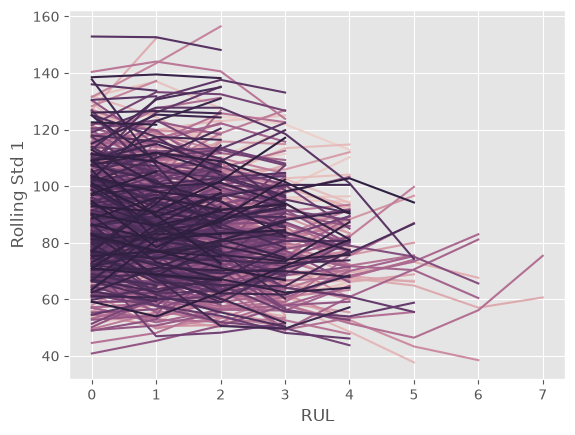

In [20]:
epi_tool["Rolling Std 1"] = epi_tool.groupby("Cycle Group")["Input 1"].rolling(7).std().reset_index(level=0,drop=True)
epi_tool["Rolling Std 2"] = epi_tool.groupby("Cycle Group")["Input 2"].rolling(7).std().reset_index(level=0,drop=True)
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Std 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Std 2'>

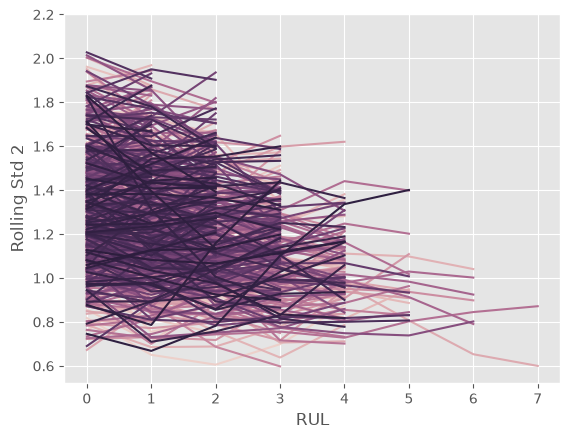

In [21]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Std 2", hue="Cycle Group", legend = False)

In [22]:
n = 5
epi_tool["Shift1"] = epi_tool.groupby("Cycle Group")["Rolling Mean 1"].shift(n)
epi_tool["RoC1"] = epi_tool["Rolling Mean 1"] - epi_tool["Shift1"]

epi_tool["Shift2"] = epi_tool.groupby("Cycle Group")["Rolling Mean 2"].shift(n)
epi_tool["RoC2"] = epi_tool["Rolling Mean 2"] - epi_tool["Shift2"]

<Axes: xlabel='RUL', ylabel='RoC1'>

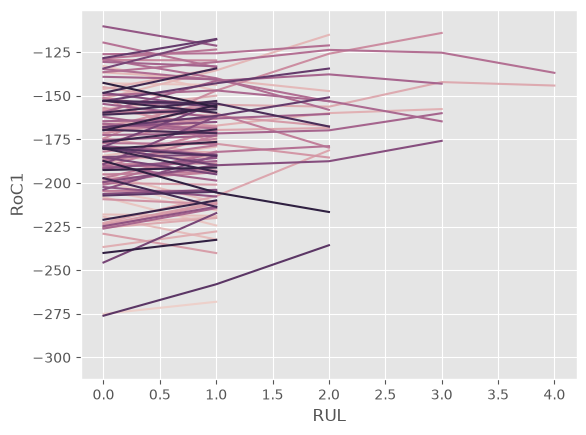

In [23]:
sns.lineplot(data=epi_tool, x="RUL", y="RoC1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='RoC2'>

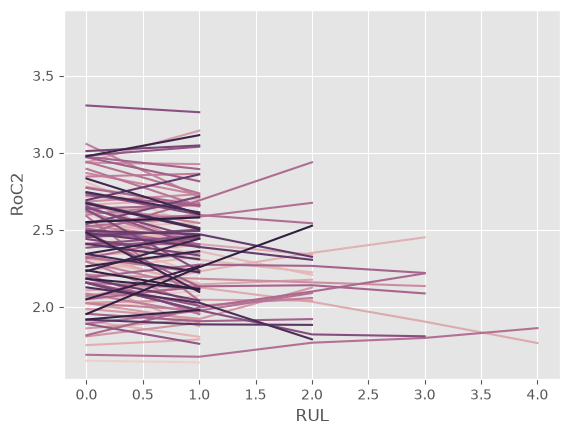

In [24]:
sns.lineplot(data=epi_tool, x="RUL", y="RoC2", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Output'>

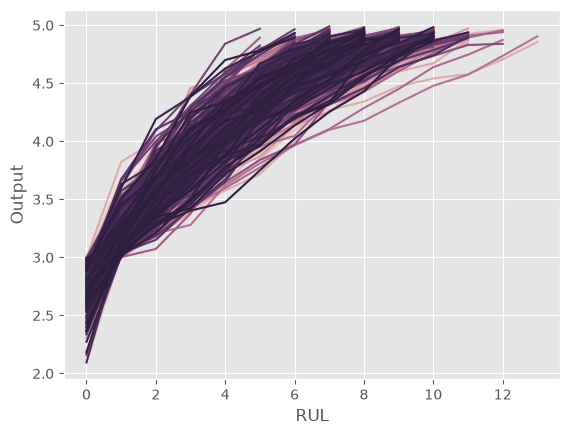

In [25]:
sns.lineplot(data=epi_tool, x="RUL", y="Output", hue="Cycle Group", legend=False)